In [61]:
#imports and data loading
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

df = sns.load_dataset("titanic")

print("Shape:", df.shape)
df.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [63]:
#drop the duplicate columns
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    object  
 3   age          678 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     782 non-null    object  
 8   class        784 non-null    category
 9   who          784 non-null    object  
 10  adult_male   784 non-null    bool    
 11  deck         202 non-null    category
 12  embark_town  782 non-null    object  
 13  alive        784 non-null    object  
 14  alone        784 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 77.0+ KB


In [64]:
#drop unnecessary columns
df=df.drop(columns=['deck','embark_town','alive','adult_male','who','class'],axis=1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  784 non-null    int64  
 1   pclass    784 non-null    int64  
 2   sex       784 non-null    object 
 3   age       678 non-null    float64
 4   sibsp     784 non-null    int64  
 5   parch     784 non-null    int64  
 6   fare      784 non-null    float64
 7   embarked  782 non-null    object 
 8   alone     784 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 55.9+ KB


In [66]:
# fill the missing values by mode
df['age'].fillna(df['age'].mode()[0], inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  784 non-null    int64  
 1   pclass    784 non-null    int64  
 2   sex       784 non-null    object 
 3   age       784 non-null    float64
 4   sibsp     784 non-null    int64  
 5   parch     784 non-null    int64  
 6   fare      784 non-null    float64
 7   embarked  784 non-null    object 
 8   alone     784 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 55.9+ KB


C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\1891875349.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mode()[0], inplace=True)
C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\1891875349.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [67]:
#age binning
bins = [0, 12, 17, 59, 120]  
labels = ['Child', 'Teen', 'Adult', 'Old']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
df.head(10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,False,Adult
1,1,1,female,38.0,1,0,71.2833,C,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,True,Adult
3,1,1,female,35.0,1,0,53.1000,S,False,Adult
4,0,3,male,35.0,0,0,8.0500,S,True,Adult
5,0,3,male,24.0,0,0,8.4583,Q,True,Adult
6,0,1,male,54.0,0,0,51.8625,S,True,Adult
7,0,3,male,2.0,3,1,21.0750,S,False,Child
8,1,3,female,27.0,0,2,11.1333,S,False,Adult
9,1,2,female,14.0,1,0,30.0708,C,False,Teen


In [ ]:
#convert categorical columns to numeric
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['alone'] = df['alone'].astype(int)
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_group
0,0,3,0,22.0,1,0,7.2500,0,0,Adult
1,1,1,1,38.0,1,0,71.2833,1,0,Adult
2,1,3,1,26.0,0,0,7.9250,0,1,Adult
3,1,1,1,35.0,1,0,53.1000,0,0,Adult
4,0,3,0,35.0,0,0,8.0500,0,1,Adult
5,0,3,0,24.0,0,0,8.4583,2,1,Adult
6,0,1,0,54.0,0,0,51.8625,0,1,Adult
7,0,3,0,2.0,3,1,21.0750,0,0,Child
8,1,3,1,27.0,0,2,11.1333,0,0,Adult
9,1,2,1,14.0,1,0,30.0708,1,0,Teen


In [ ]:
#handling outliers on age column using IQR method

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1  

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['age'] = np.where(df['age'] > upper_limit, upper_limit,
            np.where(df['age'] < lower_limit, lower_limit, df['age']))

df['age'].describe()


count    784.000000
mean      28.797832
std       13.171926
min        1.000000
25%       22.000000
50%       26.000000
75%       36.000000
max       57.000000
Name: age, dtype: float64

In [70]:
#normalization using min-max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['fare'] = scaler.fit_transform(df[['fare']])
df['fare'].describe()

count    784.000000
mean       0.067753
std        0.101810
min        0.000000
25%        0.015713
50%        0.031035
75%        0.066577
max        1.000000
Name: fare, dtype: float64

In [71]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_group
0,0,3,0,22.0,1,0,0.014151,0,0,Adult
1,1,1,1,38.0,1,0,0.139136,1,0,Adult
2,1,3,1,26.0,0,0,0.015469,0,1,Adult
3,1,1,1,35.0,1,0,0.103644,0,0,Adult
4,0,3,0,35.0,0,0,0.015713,0,1,Adult
5,0,3,0,24.0,0,0,0.016510,2,1,Adult
6,0,1,0,54.0,0,0,0.101229,0,1,Adult
7,0,3,0,2.0,3,1,0.041136,0,0,Child
8,1,3,1,27.0,0,2,0.021731,0,0,Adult
9,1,2,1,14.0,1,0,0.058694,1,0,Teen


In [72]:
#simple feature engineering

#create a 'family_size' column
df['family_size'] = df['sibsp'] + df['parch'] + 1

#create a 'fare_per_person' column 
df['fare_per_person'] = df['fare'] / df['family_size']

#create an 'is_female_alone' column 
df['is_female_alone'] = ((df['sex'] == 1) & (df['alone'] == 1)).astype(int)

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_group,family_size,fare_per_person,is_female_alone
0,0,3,0,22.0,1,0,0.014151,0,0,Adult,2,0.007076,0
1,1,1,1,38.0,1,0,0.139136,1,0,Adult,2,0.069568,0
2,1,3,1,26.0,0,0,0.015469,0,1,Adult,1,0.015469,1
3,1,1,1,35.0,1,0,0.103644,0,0,Adult,2,0.051822,0
4,0,3,0,35.0,0,0,0.015713,0,1,Adult,1,0.015713,0


C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\3571428377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='age', data=df, palette='Set2')


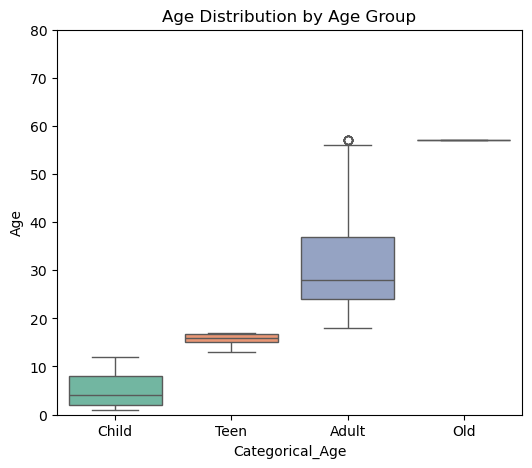

In [78]:
#bucketed age group visualization
plt.figure(figsize=(6,5))

sns.boxplot(x='age_group', y='age', data=df, palette='Set2')

plt.title('Age Distribution by Age Group')
plt.xlabel('Categorical_Age')
plt.ylabel('Age')
plt.ylim(0, 80)
plt.show()

C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\2653976529.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_group', data=df, palette='Blues')


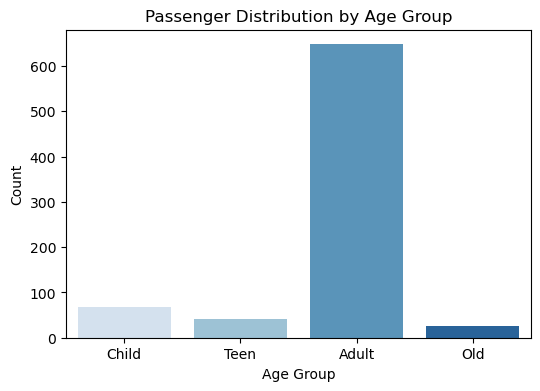

In [73]:
#visualization of age group distribution

plt.figure(figsize=(6,4))

sns.countplot(x='age_group', data=df, palette='Blues')

plt.title('Passenger Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\2459874472.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['sex'].map({0: 'Male', 1: 'Female'}), y='survived', data=df, palette='pastel')


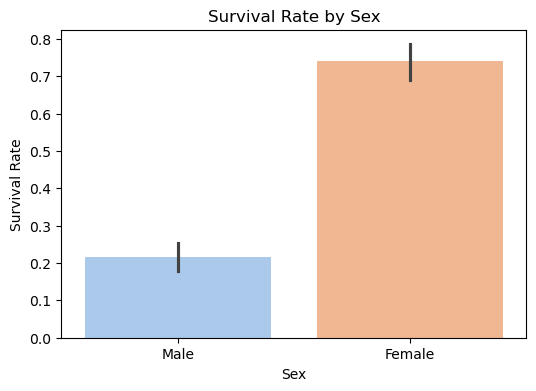

In [80]:
#survival rate by sex
plt.figure(figsize=(6,4))

sns.barplot(x=df['sex'].map({0: 'Male', 1: 'Female'}), y='survived', data=df, palette='pastel')

plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')  
plt.show()

C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\388277418.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'}),y=df['survived'],palette='pastel')


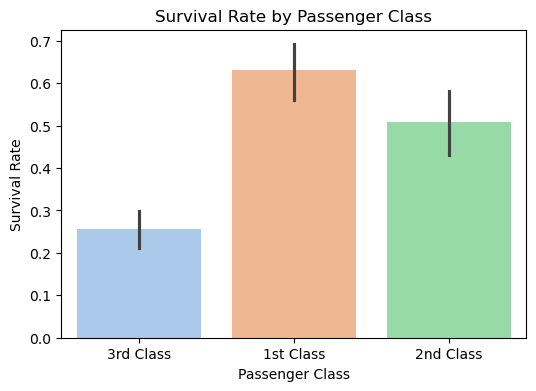

In [ ]:
#survival rate by passenger class
plt.figure(figsize=(6,4))

sns.barplot(x=df['pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'}), y=df['survived'], palette='pastel')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\2507101014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='survived', data=df, palette='pastel')


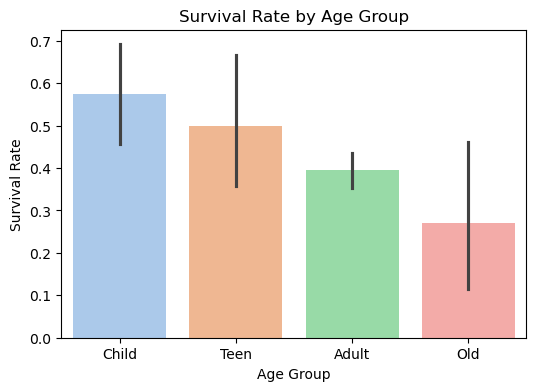

In [84]:
#survival rate by age group
plt.figure(figsize=(6,4))

sns.barplot(x='age_group', y='survived', data=df, palette='pastel')

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

C:\Users\Tanvir Ahmed\AppData\Local\Temp\ipykernel_6520\2889366153.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='fare', data=df, palette='Set2')


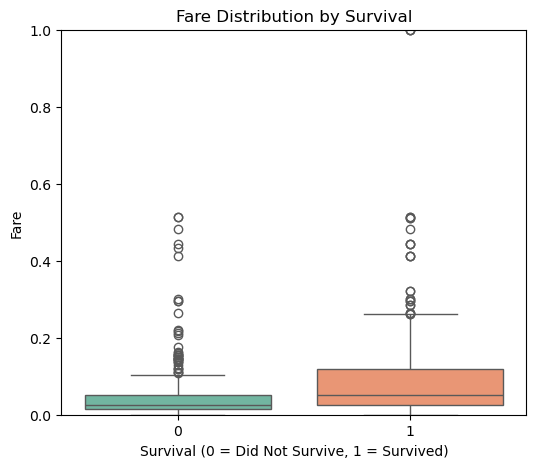

In [ ]:
#fare distribution by survival
plt.figure(figsize=(6,5))

sns.boxplot(x='survived', y='fare', data=df, palette='Set2')

plt.title('Fare Distribution by Survival')
plt.xlabel('Survival (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Fare')
plt.ylim(0, df['fare'].max())  # optional: keep y-axis within valid range
plt.show()

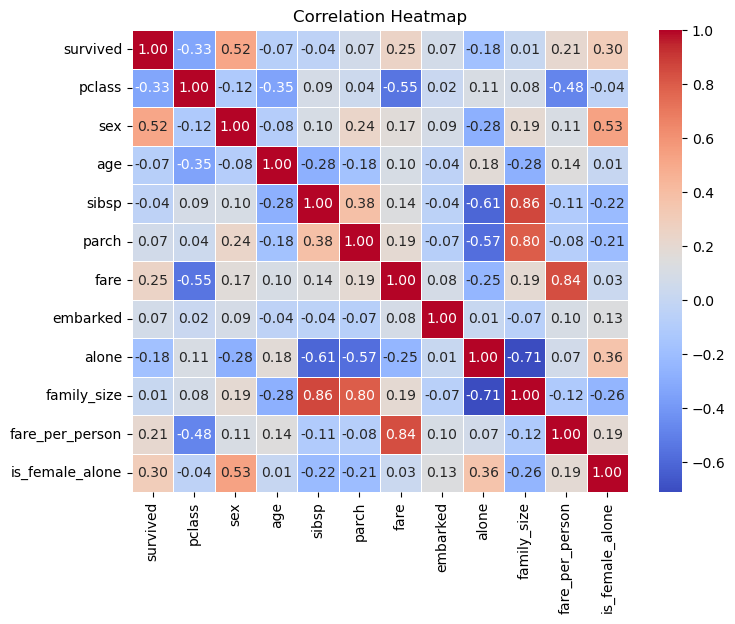

In [ ]:
#correlation heatmap
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()